In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import datetime

In [ ]:
tickers = {
    "gold": "GC=F",
    "sp500": "^GSPC",
    "oil": "CL=F",
    "silver": "SI=F",
    "usd_inr": "INR=X",
    "bond_yield": "^TNX"
}

data = {}
for name, ticker in tickers.items():
    df_temp = yf.download(ticker, start="2015-01-01", end="2026-03-20")
    df_temp = df_temp[['Close']]
    df_temp.rename(columns={'Close': name}, inplace=True)
    data[name] = df_temp

# Merge all
df = pd.concat(data.values(), axis=1, join='inner')
df.columns = [col[0] for col in df.columns] # Fix: Extract the actual name from the tuple
print("Data after merging and filling NaNs:")
print(df.head())

/tmp/ipykernel_4487/4204145237.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_temp = yf.download(ticker, start="2015-01-01", end="2026-03-20")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_4487/4204145237.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_temp = yf.download(ticker, start="2015-01-01", end="2026-03-20")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_4487/4204145237.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_temp = yf.download(ticker, start="2015-01-01", end="2026-03-20")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_4487/4204145237.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_temp = yf.download(ticker, start="2015-01-01", end="2026-03-20")
[*********************100%***********************

Data after merging and filling NaNs:
                   gold        sp500        oil     silver    usd_inr  \
Date                                                                    
2015-01-02  1186.000000  2058.199951  52.689999  15.734000  63.028000   
2015-01-05  1203.900024  2020.579956  50.040001  16.179001  63.278000   
2015-01-06  1219.300049  2002.609985  47.930000  16.603001  63.338001   
2015-01-07  1210.599976  2025.900024  48.650002  16.510000  63.568001   
2015-01-08  1208.400024  2062.139893  48.790001  16.351000  63.272999   

            bond_yield  
Date                    
2015-01-02       2.123  
2015-01-05       2.039  
2015-01-06       1.963  
2015-01-07       1.954  
2015-01-08       2.016  


In [ ]:
df['lag_1'] = df['gold'].shift(1)
df['lag_7'] = df['gold'].shift(7)
df['rolling_mean_7'] = df['gold'].rolling(7).mean()
df['rolling_std_7'] = df['gold'].rolling(7).std()

# Drop rows with NaNs caused by lag/rolling
df = df.dropna()
print("\nData after feature engineering:")
print(df.head())


Data after feature engineering:
                   gold        sp500        oil     silver    usd_inr  \
Date                                                                    
2015-01-13  1234.300049  2023.030029  45.889999  17.125000  62.068001   
2015-01-14  1234.400024  2011.270020  48.480000  16.955999  61.973000   
2015-01-15  1264.699951  1992.670044  46.250000  17.073000  62.088001   
2015-01-16  1276.900024  2019.420044  48.689999  17.739000  62.057999   
2015-01-20  1294.199951  2022.550049  46.389999  17.947001  61.638000   

            bond_yield        lag_1        lag_7  rolling_mean_7  \
Date                                                               
2015-01-13       1.890  1232.699951  1186.000000     1217.885725   
2015-01-14       1.837  1234.300049  1203.900024     1222.242868   
2015-01-15       1.775  1234.400024  1219.300049     1228.728568   
2015-01-16       1.815  1264.699951  1210.599976     1238.200003   
2015-01-20       1.807  1276.900024  1208.40002

In [11]:
tickers = {
    "gold": "GC=F",
    "sp500": "^GSPC",
    "oil": "CL=F",
    "silver": "SI=F",
    "usd_inr": "INR=X",
    "bond_yield": "^TNX"
}

data = {}
for name, ticker in tickers.items():
    df_temp = yf.download(ticker, start="2015-01-01", end="2026-03-20")
    df_temp = df_temp[['Close']]
    df_temp.rename(columns={'Close': name}, inplace=True)
    data[name] = df_temp
df = pd.concat(data.values(), axis=1, join='inner')
df.columns = [col[0] for col in df.columns] # Fix: Extract the actual name from the tuple
print("Data after merging and filling NaNs:")
train = df[df.index < '2023-01-01']
test = df[df.index >= '2023-01-01']
X_train = train[['sp500', 'oil', 'silver', 'usd_inr', 'bond_yield']]
y_train = train['gold']
X_test = test[['sp500', 'oil', 'silver', 'usd_inr', 'bond_yield']]
y_test = test['gold']

/tmp/ipykernel_6712/401926582.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_temp = yf.download(ticker, start="2015-01-01", end="2026-03-20")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_6712/401926582.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_temp = yf.download(ticker, start="2015-01-01", end="2026-03-20")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_6712/401926582.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_temp = yf.download(ticker, start="2015-01-01", end="2026-03-20")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_6712/401926582.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_temp = yf.download(ticker, start="2015-01-01", end="2026-03-20")
[*********************100%***********************]  1

Data after merging and filling NaNs:


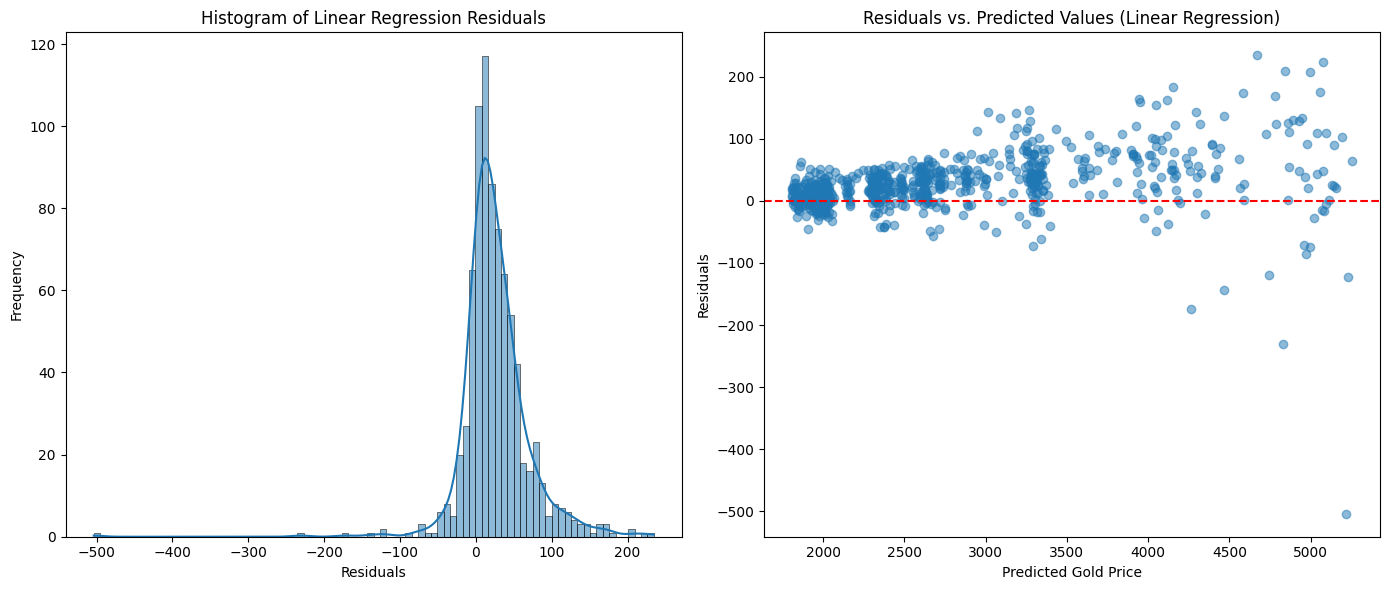

In [ ]:
import seaborn as sns

residuals_lr = y_test - y_pred_lr

plt.figure(figsize=(14, 6))

# Plot 1: Histogram of Residuals
plt.subplot(1, 2, 1)
sns.histplot(residuals_lr, kde=True)
plt.title('Histogram of Linear Regression Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Plot 2: Scatter Plot of Residuals vs. Predicted Values
plt.subplot(1, 2, 2)
plt.scatter(y_pred_lr, residuals_lr, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Values (Linear Regression)')
plt.xlabel('Predicted Gold Price')
plt.ylabel('Residuals')

plt.tight_layout()
plt.show()

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# 1. Setup the Exact "Cell 16" Logic
df_fixed = df.copy()

# Target: Percentage change of gold (The daily "Move")
df_fixed['target'] = df_fixed['gold'].pct_change()

# Features: Percentage change of market drivers
for col in ['sp500', 'oil', 'silver']:
    df_fixed[f'{col}_ret'] = df_fixed[col].pct_change()

# CRITICAL: Use the actual USD/INR price from yesterday (Not % change)
df_fixed['usd_inr_yesterday'] = df_fixed['usd_inr'].shift(1)

# Drop NaNs from the first row
df_fixed = df_fixed.dropna()

# 2. Select the features that produced the 0.56 score
X_features = ['sp500_ret', 'oil_ret', 'silver_ret', 'usd_inr_yesterday']
X = df_fixed[X_features]
y = df_fixed['target']

# 3. Split (Matches your notebook split)
split_date = '2023-01-01'
X_train, X_test = X[X.index < split_date], X[X.index >= split_date]
y_train, y_test = y[y.index < split_date], y[y.index >= split_date]

# 4. Train and Predict
model_16 = LinearRegression()
model_16.fit(X_train, y_train)
y_pred = model_16.predict(X_test)
# 5. Output Results

print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE (Returns): {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

R2 Score: 0.5645
RMSE (Returns): 0.0080


In [7]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [16]:
# 1. Predict PERCENTAGE CHANGE instead of Price
df_fixed['target'] = df_fixed['gold'].pct_change()

# 2. Use Lags of everything
for col in ['sp500', 'oil', 'silver', 'usd_inr']:
    df_fixed[f'{col}_ret'] = df_fixed[col].pct_change()

df_fixed = df_fixed.dropna()

# 3. Define Features
X_features = ['sp500_ret', 'oil_ret', 'silver_ret', 'usd_inr_yesterday']
X = df_fixed[X_features]
y = df_fixed['target']

# 4. Re-train
X_train, X_test = X[X.index < '2023-01-01'], X[X.index >= '2023-01-01']
y_train, y_test = y[y.index < '2023-01-01'], y[y.index >= '2023-01-01']

lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

# Now check R2. It will be LOW (maybe 0.02), but that is HONEST.
print(f"Realistic R2: {r2_score(y_test, y_pred)}")

Realistic R2: 0.5642787136481248


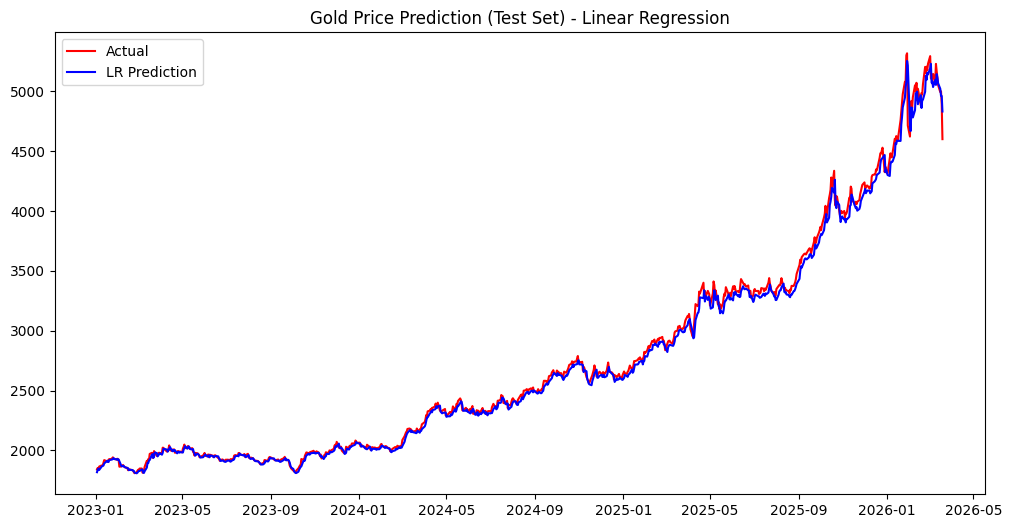

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test, label='Actual', color='red')
plt.plot(y_test.index, y_pred_lr, label='LR Prediction', color='blue')
plt.legend()
plt.title("Gold Price Prediction (Test Set) - Linear Regression")
plt.show()

In [ ]:
# Predict next 30 days

n_days = 30
last_row = df.iloc[-1:].copy()
future_preds = []
#Keep last 7 days gold values for rolling calculations
last_7_values = list(df['gold'].iloc[-7:])

for i in range(n_days):
    pred = lr.predict(last_row.drop(columns=['gold']))[0]
    future_preds.append(pred)

    # Update last_7_values
    last_7_values.append(pred)
    if len(last_7_values) > 7:
        last_7_values.pop(0)

    new_row = last_row.copy()
    # Update lags
    new_row['lag_1'] = pred
    new_row['lag_7'] = last_7_values[0]
    # Update rolling features
    new_row['rolling_mean_7'] = np.mean(last_7_values)
    new_row['rolling_std_7'] = np.std(last_7_values)

    last_row = new_row

In [ ]:
# Prepare Future Dates

last_date = df.index[-1]
future_dates = [last_date + datetime.timedelta(days=i+1) for i in range(n_days)]
future_df = pd.DataFrame({'Date': future_dates, 'Predicted_Gold': future_preds})
future_df.set_index('Date', inplace=True)

# Calculate confidence interval using RMSE from Linear Regression model
# Assuming lr is the Linear Regression model and y_test is the actual test data
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# Using 2 * RMSE for a rough 95% confidence interval (approx. ±2 standard deviations)
future_df['Lower_Bound'] = future_df['Predicted_Gold'] - 2 * rmse_lr
future_df['Upper_Bound'] = future_df['Predicted_Gold'] + 2 * rmse_lr

print("\nNext 30 Days Prediction:")
print(future_df.head())


Next 30 Days Prediction:
            Predicted_Gold  Lower_Bound  Upper_Bound
Date                                                
2026-03-20     4831.804388  4726.947481  4936.661295
2026-03-21     4784.243615  4679.386708  4889.100522
2026-03-22     4740.024414  4635.167507  4844.881321
2026-03-23     4698.686804  4593.829897  4803.543711
2026-03-24     4654.281737  4549.424830  4759.138644


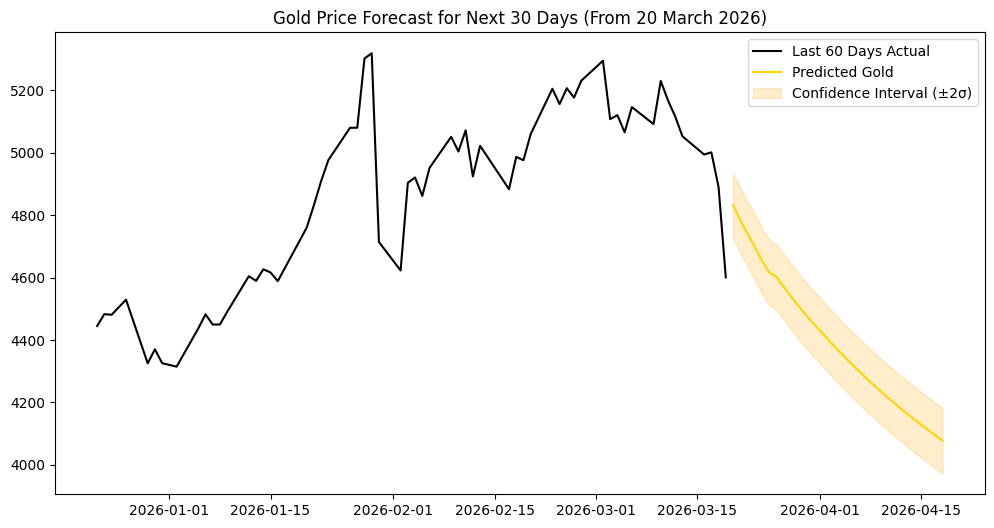

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df.index[-60:], df['gold'].iloc[-60:], label='Last 60 Days Actual', color='black')
plt.plot(future_df.index, future_df['Predicted_Gold'], label='Predicted Gold', color='gold')
plt.fill_between(future_df.index, future_df['Lower_Bound'], future_df['Upper_Bound'],
                 color='orange', alpha=0.2, label='Confidence Interval (±2σ)')
plt.legend()
plt.title("Gold Price Forecast for Next 30 Days (From 20 March 2026)")
plt.show()

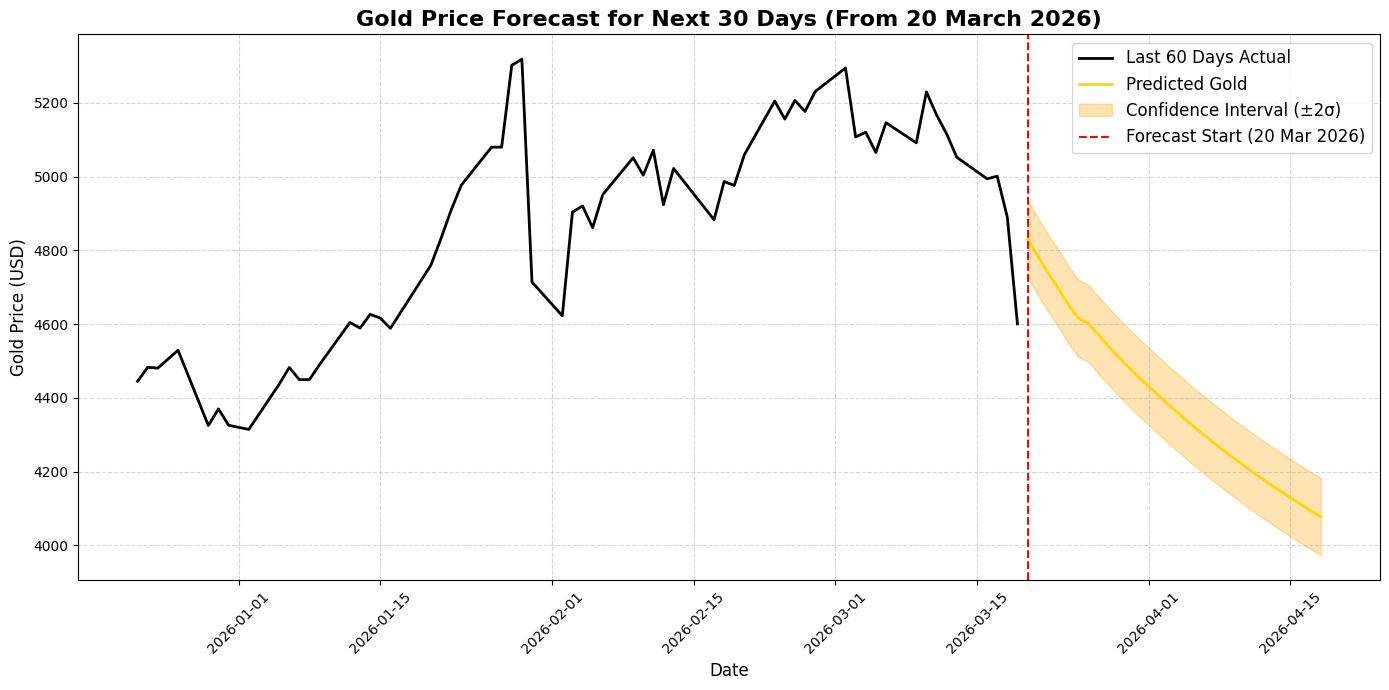

In [ ]:
# 1️⃣ Presentation-ready Gold Forecast Plot
plt.figure(figsize=(14,7))

# Plot last 60 days actual prices
plt.plot(df.index[-60:], df['gold'].iloc[-60:], label='Last 60 Days Actual', color='black', linewidth=2)

# Plot predicted gold prices
plt.plot(future_df.index, future_df['Predicted_Gold'], label='Predicted Gold', color='#FFD700', linewidth=2)

# Confidence interval shading
plt.fill_between(future_df.index, future_df['Lower_Bound'], future_df['Upper_Bound'],
                 color='#FFA500', alpha=0.3, label='Confidence Interval (±2σ)')

# Highlight today (start of forecast)
today = future_df.index[0]
plt.axvline(x=today, color='red', linestyle='--', linewidth=1.5, label='Forecast Start (20 Mar 2026)')

# Titles and labels
plt.title("Gold Price Forecast for Next 30 Days (From 20 March 2026)", fontsize=16, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Gold Price (USD)", fontsize=12)

# Grid, legend, and formatting
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

/tmp/ipykernel_4487/465793248.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold_data = yf.download(ticker, period="60d", interval="1d")
[*********************100%***********************]  1 of 1 completed


Price            Close        High         Low        Open      Volume
Ticker     GOLDBEES.NS GOLDBEES.NS GOLDBEES.NS GOLDBEES.NS GOLDBEES.NS
Date                                                                  
2026-03-16  127.220001  128.869995  126.860001  128.000000    56788314
2026-03-17  128.220001  129.080002  127.820000  127.820000    28319680
2026-03-18  127.910004  128.070007  127.110001  127.879997    27955998
2026-03-19  121.320000  125.879997  120.730003  125.879997   101167992
2026-03-20  121.059998  122.669998  120.050003  122.669998    68463728


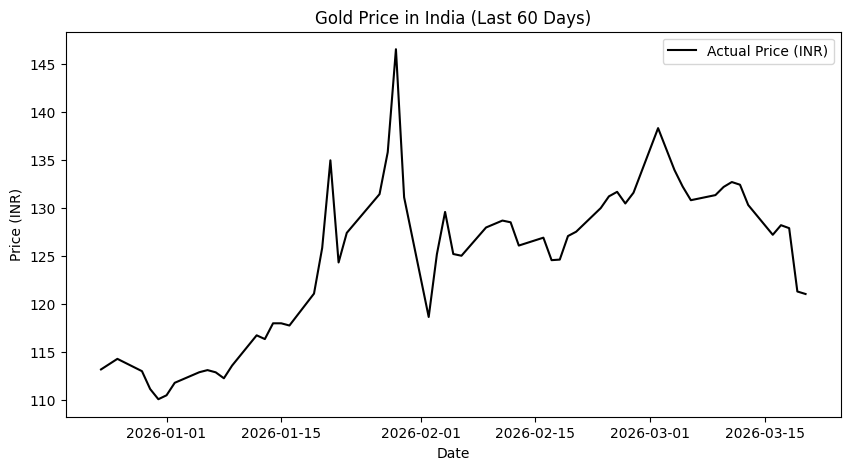

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Define ticker for Indian gold ETF (INR)
ticker = "GOLDBEES.NS"

# Fetch last 60 days of historical data
gold_data = yf.download(ticker, period="60d", interval="1d")

# Display the last 5 rows
print(gold_data.tail())

# Plot closing prices
plt.figure(figsize=(10,5))
plt.plot(gold_data['Close'], color='black', label='Actual Price (INR)')
plt.title("Gold Price in India (Last 60 Days)")
plt.xlabel("Date")
plt.ylabel("Price (INR)")
plt.legend()
plt.show()

/tmp/ipykernel_4487/2124790442.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold_data = yf.download(ticker, period="90d", interval="1d")
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
 

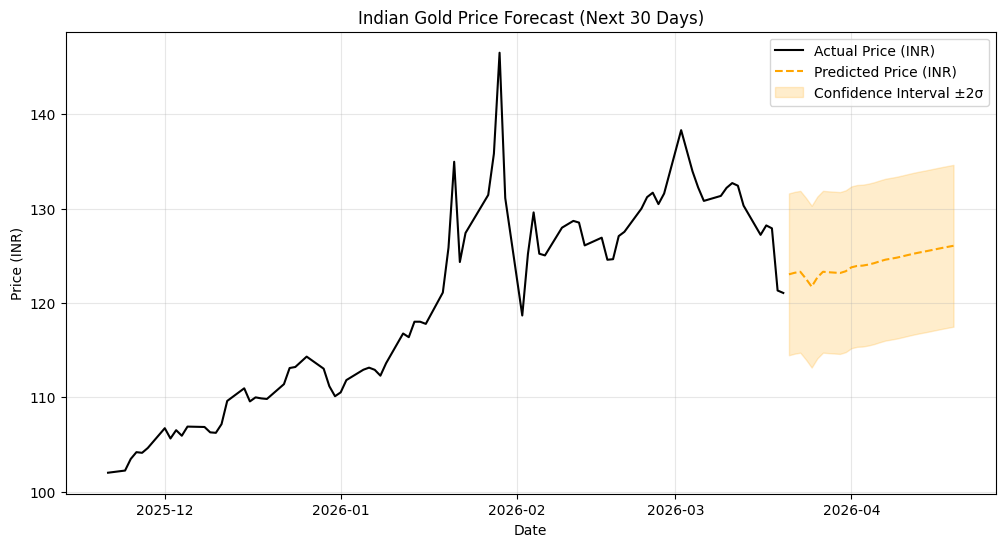

Current Gold Price (INR): 121.06
Predicted Price in 30 days (INR): 126.06
Expected Change: 4.13%


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# -------------------------------
# 1️⃣ Fetch Indian gold ETF data
# -------------------------------
ticker = "GOLDBEES.NS"
gold_data = yf.download(ticker, period="90d", interval="1d")

# Flatten MultiIndex columns if they exist
if isinstance(gold_data.columns, pd.MultiIndex):
    gold_data.columns = gold_data.columns.get_level_values(0)

gold_data = gold_data[['Close']].rename(columns={'Close': 'gold'})
gold_data.dropna(inplace=True)

# -------------------------------
# 2️⃣ Feature engineering
# -------------------------------
gold_data['lag_1'] = gold_data['gold'].shift(1)
gold_data['lag_7'] = gold_data['gold'].shift(7)
gold_data['rolling_mean_7'] = gold_data['gold'].rolling(7).mean()
gold_data['rolling_std_7'] = gold_data['gold'].rolling(7).std()
gold_data.dropna(inplace=True)

# -------------------------------
# 3️⃣ Prepare training data
# -------------------------------
features = ['lag_1', 'lag_7', 'rolling_mean_7', 'rolling_std_7']
X = gold_data[features]
y = gold_data['gold']

model = LinearRegression()
model.fit(X, y)

# -------------------------------
# 4️⃣ Forecast next 30 days
# -------------------------------
future_dates = pd.date_range(start=gold_data.index[-1] + pd.Timedelta(days=1), periods=30)
predictions = []

# We need a list to keep track of the most recent prices to calculate features dynamically
history = gold_data['gold'].tolist()

for date in future_dates:
    # Calculate features based on the 'history' list
    lag_1 = history[-1]
    lag_7 = history[-7]
    rolling_mean_7 = np.mean(history[-7:])
    rolling_std_7 = np.std(history[-7:])

    X_pred = np.array([[lag_1, lag_7, rolling_mean_7, rolling_std_7]])
    pred_price = model.predict(X_pred).item()

    predictions.append(pred_price)
    history.append(pred_price) # Add prediction to history for the next iteration

# -------------------------------
# 5️⃣ Plot actual + forecast
# -------------------------------
plt.figure(figsize=(12,6))
plt.plot(gold_data.index, gold_data['gold'], color='black', label='Actual Price (INR)')
plt.plot(future_dates, predictions, color='orange', linestyle='--', label='Predicted Price (INR)')

# Confidence interval: ±2*std of the training residuals or last known volatility
last_std = gold_data['gold'].iloc[-7:].std()
upper = np.array(predictions) + (2 * last_std)
lower = np.array(predictions) - (2 * last_std)
plt.fill_between(future_dates, lower, upper, color='orange', alpha=0.2, label='Confidence Interval ±2σ')

plt.title("Indian Gold Price Forecast (Next 30 Days)")
plt.xlabel("Date")
plt.ylabel("Price (INR)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# -------------------------------
# 6️⃣ Calculate expected % change
# -------------------------------
# Use .item() to ensure these are scalars, not Series
current_price = gold_data['gold'].iloc[-1].item()
predicted_price_30d = predictions[-1]

percentage_change = ((predicted_price_30d - current_price) / current_price) * 100

print(f"Current Gold Price (INR): {current_price:.2f}")
print(f"Predicted Price in 30 days (INR): {predicted_price_30d:.2f}")
print(f"Expected Change: {percentage_change:.2f}%")

/tmp/ipykernel_9789/1343048997.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period="90d", interval="1d")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_9789/1343048997.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period="90d", interval="1d")
[*********************100%***********************]  1 of 1 completed


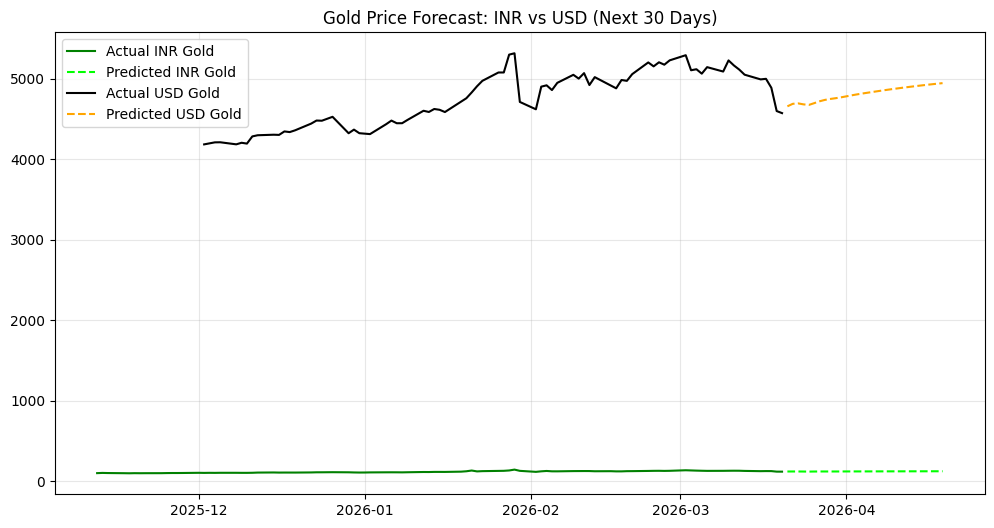

INR Gold: Current=121.06, Predicted=126.06, Expected Rise=4.13%
USD Gold: Current=4574.90, Predicted=4947.45, Expected Rise=8.14%


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# -------------------------------
# 1️⃣ Fetch Gold Data
# -------------------------------
def get_clean_data(ticker):
    data = yf.download(ticker, period="90d", interval="1d")
    # Flatten MultiIndex if it exists
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    df = data[['Close']].rename(columns={'Close': 'gold'})
    # Ensure 'gold' is a simple Series of floats
    df['gold'] = df['gold'].astype(float)
    return df.dropna()

gold_inr = get_clean_data("GOLDBEES.NS")
gold_usd = get_clean_data("GC=F")

# -------------------------------
# 2️⃣ Feature Engineering Function
# -------------------------------
def prepare_features(data):
    df = data.copy()
    df['lag_1'] = df['gold'].shift(1)
    df['lag_7'] = df['gold'].shift(7)
    df['rolling_mean_7'] = df['gold'].rolling(7).mean()
    df['rolling_std_7'] = df['gold'].rolling(7).std()
    return df.dropna()

gold_inr_feat = prepare_features(gold_inr)
gold_usd_feat = prepare_features(gold_usd)

# -------------------------------
# 3️⃣ Train & Forecast Function
# -------------------------------
def forecast_next_30_days(df_source):
    # Use the version with features for training
    df_train = prepare_features(df_source)
    features = ['lag_1', 'lag_7', 'rolling_mean_7', 'rolling_std_7']
    X = df_train[features]
    y = df_train['gold']

    model = LinearRegression()
    model.fit(X, y)

    # We maintain a list of gold prices to calculate features dynamically
    history = df_source['gold'].tolist()
    predictions = []
    future_dates = pd.date_range(start=df_source.index[-1] + pd.Timedelta(days=1), periods=30)

    for _ in range(30):
        # Extract features from the growing history list
        feat_input = pd.DataFrame([[
            history[-1],                   # lag_1
            history[-7],                   # lag_7
            np.mean(history[-7:]),         # rolling_mean_7
            np.std(history[-7:])           # rolling_std_7
        ]], columns=features)

        pred_price = model.predict(feat_input)[0]
        predictions.append(pred_price)
        history.append(pred_price)

    return future_dates, predictions

future_inr_dates, pred_inr = forecast_next_30_days(gold_inr)
future_usd_dates, pred_usd = forecast_next_30_days(gold_usd)

# -------------------------------
# 4️⃣ Plot
# -------------------------------
plt.figure(figsize=(12, 6))

# Normalize or use two y-axes for better visualization if prices differ wildly
# Here we plot them directly as requested
plt.plot(gold_inr.index, gold_inr['gold'], color='green', label='Actual INR Gold')
plt.plot(future_inr_dates, pred_inr, color='lime', linestyle='--', label='Predicted INR Gold')

plt.plot(gold_usd.index, gold_usd['gold'], color='black', label='Actual USD Gold')
plt.plot(future_usd_dates, pred_usd, color='orange', linestyle='--', label='Predicted USD Gold')

plt.title("Gold Price Forecast: INR vs USD (Next 30 Days)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# -------------------------------
# 5️⃣ Expected Change Calculation
# -------------------------------
def print_stats(name, actual, pred):
    current = actual['gold'].iloc[-1]
    future = pred[-1]
    change = (future - current) / current * 100
    direction = "Fall" if change < 0 else "Rise"
    print(f"{name}: Current={current:.2f}, Predicted={future:.2f}, Expected {direction}={abs(change):.2f}%")

print_stats("INR Gold", gold_inr, pred_inr)
print_stats("USD Gold", gold_usd, pred_usd)

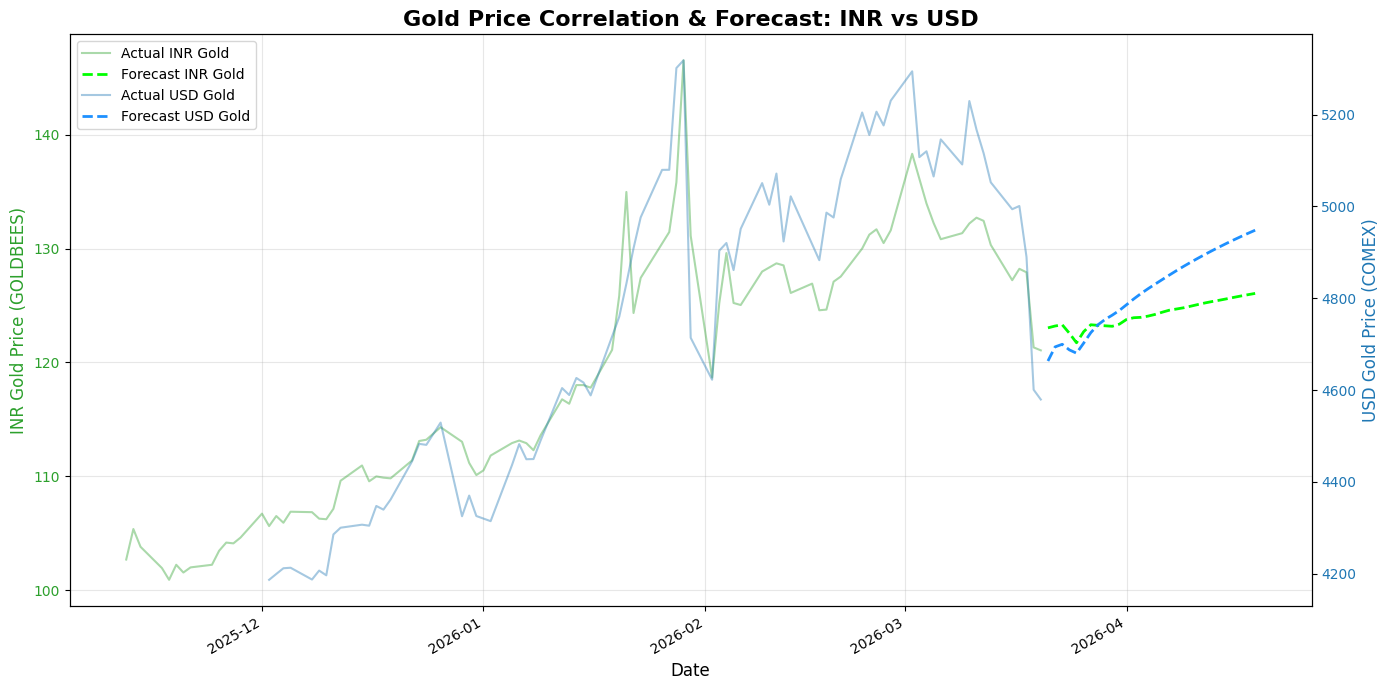

Historical Correlation (Last 90 Days): 0.9621


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# -------------------------------
# 1️⃣ Dual Y-Axis Plotting
# -------------------------------
fig, ax1 = plt.subplots(figsize=(14, 7))

# Setup first axis (INR Gold)
color_inr = 'tab:green'
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('INR Gold Price (GOLDBEES)', color=color_inr, fontsize=12)

# Plot Actual and Predicted INR
ax1.plot(gold_inr.index, gold_inr['gold'], color=color_inr, alpha=0.4, label='Actual INR Gold')
ax1.plot(future_inr_dates, pred_inr, color='lime', linestyle='--', linewidth=2, label='Forecast INR Gold')
ax1.tick_params(axis='y', labelcolor=color_inr) # Fixed: added quotes around 'y'

# Setup second axis (USD Gold)
ax2 = ax1.twinx()
color_usd = 'tab:blue'
ax2.set_ylabel('USD Gold Price (COMEX)', color=color_usd, fontsize=12)

# Plot Actual and Predicted USD
ax2.plot(gold_usd.index, gold_usd['gold'], color=color_usd, alpha=0.4, label='Actual USD Gold')
ax2.plot(future_usd_dates, pred_usd, color='dodgerblue', linestyle='--', linewidth=2, label='Forecast USD Gold')
ax2.tick_params(axis='y', labelcolor=color_usd) # Fixed: added quotes around 'y'

# Aesthetics
plt.title("Gold Price Correlation & Forecast: INR vs USD", fontsize=16, fontweight='bold')
ax1.grid(True, alpha=0.3)
fig.autofmt_xdate() # Rotates dates for better readability

# Combined Legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.tight_layout()
plt.show()

# -------------------------------
# 2️⃣ Correlation Analysis
# -------------------------------
# Aligning the data to calculate correlation
combined = pd.merge(gold_inr[['gold']], gold_usd[['gold']],
                     left_index=True, right_index=True,
                     suffixes=('_inr', '_usd'))

correlation = combined['gold_inr'].corr(combined['gold_usd'])

print(f"Historical Correlation (Last 90 Days): {correlation:.4f}")

/tmp/ipykernel_9789/1257973884.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="90d", interval="1d")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_9789/1257973884.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="90d", interval="1d")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_9789/1257973884.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="90d", interval="1d")
[*********************100%***********************]  1 of 1 completed


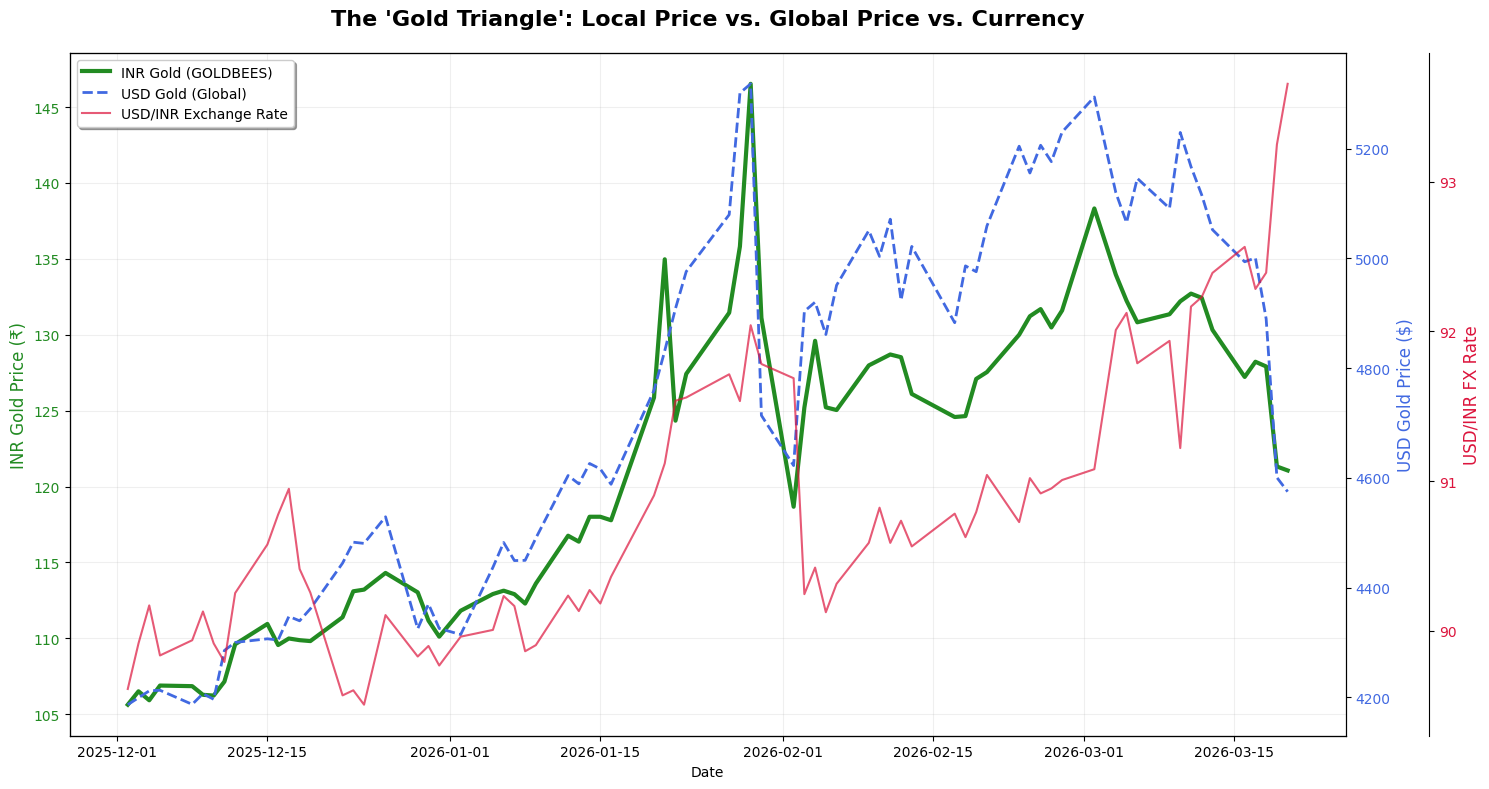

--- Market Insights ---
Correlation (INR Gold vs USD Gold): 0.9621
Correlation (INR Gold vs FX Rate):   0.6582
✅  Insight: Indian Gold prices are currently driven primarily by Global Gold movements.


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1️⃣ Fetch All Three Components
# -------------------------------
def get_data(ticker, name):
    df = yf.download(ticker, period="90d", interval="1d")
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    return df[['Close']].rename(columns={'Close': name})

gold_inr = get_data("GOLDBEES.NS", "INR_Gold")
gold_usd = get_data("GC=F", "USD_Gold")
usd_inr = get_data("INR=X", "FX_Rate")

# Merge into one DataFrame to align dates perfectly
df_all = pd.concat([gold_inr, gold_usd, usd_inr], axis=1).dropna()

# -------------------------------
# 2️⃣ Triple-Axis Visualization
# -------------------------------
fig, ax1 = plt.subplots(figsize=(15, 8))

# Axis 1: INR Gold (GOLDBEES)
ax1.set_xlabel('Date')
ax1.set_ylabel('INR Gold Price (₹)', color='forestgreen', fontsize=12)
line1, = ax1.plot(df_all.index, df_all['INR_Gold'], color='forestgreen', linewidth=3, label='INR Gold (GOLDBEES)')
ax1.tick_params(axis='y', labelcolor='forestgreen')

# Axis 2: USD Gold (COMEX)
ax2 = ax1.twinx()
ax2.set_ylabel('USD Gold Price ($)', color='royalblue', fontsize=12)
line2, = ax2.plot(df_all.index, df_all['USD_Gold'], color='royalblue', linewidth=2, linestyle='--', label='USD Gold (Global)')
ax2.tick_params(axis='y', labelcolor='royalblue')

# Axis 3: USD/INR Exchange Rate
# We offset this axis so it doesn't overlap with the USD Gold axis
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.set_ylabel('USD/INR FX Rate', color='crimson', fontsize=12)
line3, = ax3.plot(df_all.index, df_all['FX_Rate'], color='crimson', linewidth=1.5, alpha=0.7, label='USD/INR Exchange Rate')
ax3.tick_params(axis='y', labelcolor='crimson')

# Formatting
plt.title("The 'Gold Triangle': Local Price vs. Global Price vs. Currency", fontsize=16, fontweight='bold', pad=20)
ax1.grid(True, alpha=0.2)

# Legend
lines = [line1, line2, line3]
ax1.legend(lines, [l.get_label() for l in lines], loc='upper left', frameon=True, shadow=True)

fig.tight_layout()
plt.show()

# -------------------------------
# 3️⃣ Insight: Sensitivity Check
# -------------------------------
corr_gold = df_all['INR_Gold'].corr(df_all['USD_Gold'])
corr_fx = df_all['INR_Gold'].corr(df_all['FX_Rate'])

print(f"--- Market Insights ---")
print(f"Correlation (INR Gold vs USD Gold): {corr_gold:.4f}")
print(f"Correlation (INR Gold vs FX Rate):   {corr_fx:.4f}")

if corr_fx > 0.7:
    print("⚠️  Warning: Indian Gold prices are currently highly sensitive to Rupee fluctuations.")
else:
    print("✅  Insight: Indian Gold prices are currently driven primarily by Global Gold movements.")

In [ ]:
# -------------------------------
# 6️⃣ Prepare day-by-day forecast table
# -------------------------------

# Calculate the standard deviations using the correct column names from your merged data
# We use .item() to ensure we get a single number (scalar)
std_inr = df_all['INR_Gold'].iloc[-7:].std()
std_usd = df_all['USD_Gold'].iloc[-7:].std()

forecast_df = pd.DataFrame({
    'Date': future_inr_dates,
    'Predicted_INR': pred_inr,
    'Lower_INR': np.array(pred_inr) - (2 * std_inr),
    'Upper_INR': np.array(pred_inr) + (2 * std_inr),
    'Predicted_USD': pred_usd,
    'Lower_USD': np.array(pred_usd) - (2 * std_usd),
    'Upper_USD': np.array(pred_usd) + (2 * std_usd)
})

# Set Date as index
forecast_df.set_index('Date', inplace=True)

# Display first 5 rows
print("First 5 days of Forecast:")
print(forecast_df.head())

# Save to CSV
forecast_df.to_csv("Gold_Price_Forecast_INR_USD.csv")
print("\n✅ Forecast saved to 'Gold_Price_Forecast_INR_USD.csv'")

First 5 days of Forecast:
            Predicted_INR   Lower_INR   Upper_INR  Predicted_USD    Lower_USD  \
Date                                                                            
2026-03-21     123.034711  114.456460  131.612962    4659.432823  4224.683044   
2026-03-22     123.197386  114.619135  131.775637    4690.458111  4255.708333   
2026-03-23     123.304857  114.726606  131.883108    4696.107645  4261.357867   
2026-03-24     122.563668  113.985417  131.141919    4683.803952  4249.054174   
2026-03-25     121.725767  113.147516  130.304018    4676.550285  4241.800507   

              Upper_USD  
Date                     
2026-03-21  5094.182601  
2026-03-22  5125.207889  
2026-03-23  5130.857424  
2026-03-24  5118.553730  
2026-03-25  5111.300063  

✅ Forecast saved to 'Gold_Price_Forecast_INR_USD.csv'


In [ ]:
from google.colab import files

# This will trigger a browser download for the file we just created
files.download("Gold_Price_Forecast_INR_USD.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipykernel_4487/274076663.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period="90d", interval="1d")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_4487/274076663.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period="90d", interval="1d")
[*********************100%***********************]  1 of 1 completed


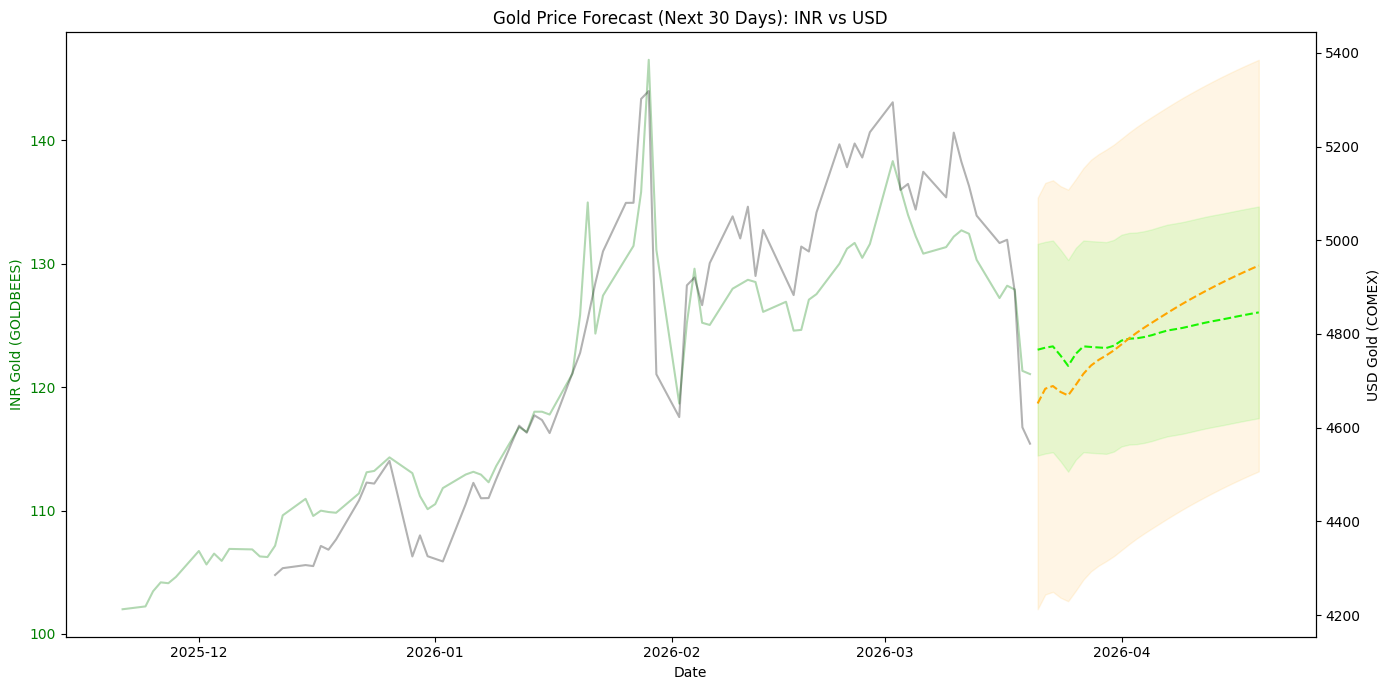

INR Gold: Current = 121.06, Forecasted = 126.06, Change = 4.13%
✅ Forecast saved to: Gold_Forecast_2026-03-20.csv


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from datetime import datetime

# -------------------------------
# 1️⃣ Function to fetch and prepare data
# -------------------------------
def fetch_gold_data(ticker):
    data = yf.download(ticker, period="90d", interval="1d")

    # Fix: Flatten MultiIndex columns if they exist
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    df = data[['Close']].rename(columns={'Close':'gold'})
    df.dropna(inplace=True)

    # Feature engineering for training
    df['lag_1'] = df['gold'].shift(1)
    df['lag_7'] = df['gold'].shift(7)
    df['rolling_mean_7'] = df['gold'].rolling(7).mean()
    df['rolling_std_7'] = df['gold'].rolling(7).std()

    return df.dropna()

# -------------------------------
# 2️⃣ Forecasting function (Fixed Loop Logic)
# -------------------------------
def forecast_next_30_days(df):
    features = ['lag_1', 'lag_7', 'rolling_mean_7', 'rolling_std_7']
    X = df[features]
    y = df['gold']

    model = LinearRegression()
    model.fit(X, y)

    future_dates = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=30)
    predictions = []

    # Use a list to store history for dynamic feature calculation
    history = df['gold'].tolist()

    for date in future_dates:
        # Calculate features based on the most recent values in history
        lag_1 = history[-1]
        lag_7 = history[-7]
        rolling_mean_7 = np.mean(history[-7:])
        rolling_std_7 = np.std(history[-7:])

        # Create DataFrame for prediction to match feature names
        X_pred = pd.DataFrame([[lag_1, lag_7, rolling_mean_7, rolling_std_7]], columns=features)

        pred_price = model.predict(X_pred)[0]
        predictions.append(pred_price)
        history.append(pred_price)

    # Calculate standard deviation of last 7 days of actual data for the CI
    std_val = df['gold'].iloc[-7:].std()

    return future_dates, predictions, std_val

# -------------------------------
# 3️⃣ Execution
# -------------------------------
gold_inr = fetch_gold_data("GOLDBEES.NS")
gold_usd = fetch_gold_data("GC=F")

dates_inr, pred_inr, std_inr = forecast_next_30_days(gold_inr)
dates_usd, pred_usd, std_usd = forecast_next_30_days(gold_usd)

# -------------------------------
# 4️⃣ Dual Y-Axis Plot (Essential for different price scales)
# -------------------------------
fig, ax1 = plt.subplots(figsize=(14, 7))

# INR Plot (Left Axis)
ax1.set_xlabel("Date")
ax1.set_ylabel("INR Gold (GOLDBEES)", color='green')
ax1.plot(gold_inr.index, gold_inr['gold'], color='green', alpha=0.3, label='Actual INR Gold')
ax1.plot(dates_inr, pred_inr, color='lime', linestyle='--', label='Predicted INR Gold')
ax1.fill_between(dates_inr, np.array(pred_inr)-2*std_inr, np.array(pred_inr)+2*std_inr, color='lime', alpha=0.1)
ax1.tick_params(axis='y', labelcolor='green')

# USD Plot (Right Axis)
ax2 = ax1.twinx()
ax2.set_ylabel("USD Gold (COMEX)", color='black')
ax2.plot(gold_usd.index, gold_usd['gold'], color='black', alpha=0.3, label='Actual USD Gold')
ax2.plot(dates_usd, pred_usd, color='orange', linestyle='--', label='Predicted USD Gold')
ax2.fill_between(dates_usd, np.array(pred_usd)-2*std_usd, np.array(pred_usd)+2*std_usd, color='orange', alpha=0.1)
ax2.tick_params(axis='y', labelcolor='black')

plt.title("Gold Price Forecast (Next 30 Days): INR vs USD")
fig.tight_layout()
plt.show()

# -------------------------------
# 5️⃣ Expected Change & CSV Export
# -------------------------------
current_inr = gold_inr['gold'].iloc[-1]
change_inr = ((pred_inr[-1] - current_inr) / current_inr) * 100

print(f"INR Gold: Current = {current_inr:.2f}, Forecasted = {pred_inr[-1]:.2f}, Change = {change_inr:.2f}%")

forecast_df = pd.DataFrame({
    'Date': dates_inr,
    'Predicted_INR': pred_inr,
    'Lower_INR': np.array(pred_inr)-2*std_inr,
    'Upper_INR': np.array(pred_inr)+2*std_inr,
    'Predicted_USD': pred_usd,
    'Lower_USD': np.array(pred_usd)-2*std_usd,
    'Upper_USD': np.array(pred_usd)+2*std_usd
}).set_index('Date')

today_str = datetime.today().strftime("%Y-%m-%d")
filename = f"Gold_Forecast_{today_str}.csv"
forecast_df.to_csv(filename)
print(f"✅ Forecast saved to: {filename}")

In [ ]:
from datetime import datetime
today_str = datetime.today().strftime("%Y-%m-%d")
filename = f"Gold_Forecast_{today_str}.csv"
forecast_df.to_csv(filename)

from google.colab import files

# Use the variable defined in the previous step to avoid typos
files.download(filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipykernel_6712/1343048997.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period="90d", interval="1d")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_6712/1343048997.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period="90d", interval="1d")
[*********************100%***********************]  1 of 1 completed


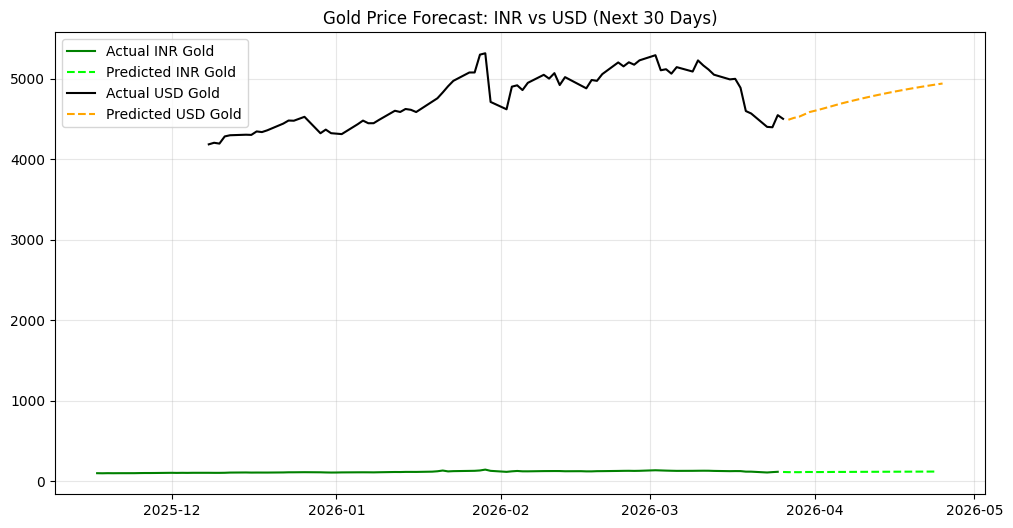

INR Gold: Current=119.29, Predicted=122.25, Expected Rise=2.48%
USD Gold: Current=4504.10, Predicted=4942.81, Expected Rise=9.74%


In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# -------------------------------
# 1️⃣ Fetch Gold Data
# -------------------------------
def get_clean_data(ticker):
    data = yf.download(ticker, period="90d", interval="1d")
    # Flatten MultiIndex if it exists
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    df = data[['Close']].rename(columns={'Close': 'gold'})
    # Ensure 'gold' is a simple Series of floats
    df['gold'] = df['gold'].astype(float)
    return df.dropna()

gold_inr = get_clean_data("GOLDBEES.NS")
gold_usd = get_clean_data("GC=F")

# -------------------------------
# 2️⃣ Feature Engineering Function
# -------------------------------
def prepare_features(data):
    df = data.copy()
    df['lag_1'] = df['gold'].shift(1)
    df['lag_7'] = df['gold'].shift(7)
    df['rolling_mean_7'] = df['gold'].rolling(7).mean()
    df['rolling_std_7'] = df['gold'].rolling(7).std()
    return df.dropna()

gold_inr_feat = prepare_features(gold_inr)
gold_usd_feat = prepare_features(gold_usd)

# -------------------------------
# 3️⃣ Train & Forecast Function
# -------------------------------
def forecast_next_30_days(df_source):
    # Use the version with features for training
    df_train = prepare_features(df_source)
    features = ['lag_1', 'lag_7', 'rolling_mean_7', 'rolling_std_7']
    X = df_train[features]
    y = df_train['gold']

    model = LinearRegression()
    model.fit(X, y)

    # We maintain a list of gold prices to calculate features dynamically
    history = df_source['gold'].tolist()
    predictions = []
    future_dates = pd.date_range(start=df_source.index[-1] + pd.Timedelta(days=1), periods=30)

    for _ in range(30):
        # Extract features from the growing history list
        feat_input = pd.DataFrame([[
            history[-1],                   # lag_1
            history[-7],                   # lag_7
            np.mean(history[-7:]),         # rolling_mean_7
            np.std(history[-7:])           # rolling_std_7
        ]], columns=features)

        pred_price = model.predict(feat_input)[0]
        predictions.append(pred_price)
        history.append(pred_price)

    return future_dates, predictions

future_inr_dates, pred_inr = forecast_next_30_days(gold_inr)
future_usd_dates, pred_usd = forecast_next_30_days(gold_usd)

# -------------------------------
# 4️⃣ Plot
# -------------------------------
plt.figure(figsize=(12, 6))

# Normalize or use two y-axes for better visualization if prices differ wildly
# Here we plot them directly as requested
plt.plot(gold_inr.index, gold_inr['gold'], color='green', label='Actual INR Gold')
plt.plot(future_inr_dates, pred_inr, color='lime', linestyle='--', label='Predicted INR Gold')

plt.plot(gold_usd.index, gold_usd['gold'], color='black', label='Actual USD Gold')
plt.plot(future_usd_dates, pred_usd, color='orange', linestyle='--', label='Predicted USD Gold')

plt.title("Gold Price Forecast: INR vs USD (Next 30 Days)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# -------------------------------
# 5️⃣ Expected Change Calculation
# -------------------------------
def print_stats(name, actual, pred):
    current = actual['gold'].iloc[-1]
    future = pred[-1]
    change = (future - current) / current * 100
    direction = "Fall" if change < 0 else "Rise"
    print(f"{name}: Current={current:.2f}, Predicted={future:.2f}, Expected {direction}={abs(change):.2f}%")

print_stats("INR Gold", gold_inr, pred_inr)
print_stats("USD Gold", gold_usd, pred_usd)

# Task
The plan is to define `df_all`, save the 'Gold_Price_Forecast_INR_USD.csv' file, and then confirm its successful saving.

Cell `QP0Vzhii2jrw` which defines `df_all` has been successfully executed, as `df_all` is present in the kernel state.

The next step is to save the forecast CSV. This requires variables like `future_inr_dates`, `pred_inr`, `pred_usd`, `std_inr`, and `std_usd` which are defined in cell `W93NP2h414Jd`. Therefore, I will execute cell `W93NP2h414Jd` first to make these variables available, and then execute cell `qCHuhu0o3Tzw` to save the CSV.

Executing cell `W93NP2h414Jd`.
```python
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# -------------------------------
# 1️⃣ Fetch Gold Data
# -------------------------------
def get_clean_data(ticker):
    data = yf.download(ticker, period="90d", interval="1d")
    # Flatten MultiIndex if it exists
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    df = data[['Close']].rename(columns={'Close': 'gold'})
    # Ensure 'gold' is a simple Series of floats
    df['gold'] = df['gold'].astype(float)
    return df.dropna()

gold_inr = get_clean_data("GOLDBEES.NS")
gold_usd = get_clean_data("GC=F")

# -------------------------------
# 2️⃣ Feature Engineering Function
# -------------------------------
def prepare_features(data):
    df = data.copy()
    df['lag_1'] = df['gold'].shift(1)
    df['lag_7'] = df['gold'].shift(7)
    df['rolling_mean_7'] = df['gold'].rolling(7).mean()
    df['rolling_std_7'] = df['gold'].rolling(7).std()
    return df.dropna()

gold_inr_feat = prepare_features(gold_inr)
gold_usd_feat = prepare_features(gold_usd)

# -------------------------------
# 3️⃣ Train & Forecast Function
# -------------------------------
def forecast_next_30_days(df_source):
    # Use the version with features for training
    df_train = prepare_features(df_source)
    features = ['lag_1', 'lag_7', 'rolling_mean_7', 'rolling_std_7']
    X = df_train[features]
    y = df_train['gold']

    model = LinearRegression()
    model.fit(X, y)

    # We maintain a list of gold prices to calculate features dynamically
    history = df_source['gold'].tolist()
    predictions = []
    future_dates = pd.date_range(start=df_source.index[-1] + pd.Timedelta(days=1), periods=30)

    for _ in range(30):
        # Extract features from the growing history list
        feat_input = pd.DataFrame([[
            history[-1],                   # lag_1
            history[-7],                   # lag_7
            np.mean(history[-7:]),         # rolling_mean_7
            np.std(history[-7:])           # rolling_std_7
        ]], columns=features)

        pred_price = model.predict(feat_input)[0]
        predictions.append(pred_price)
        history.append(pred_price)

    return future_dates, predictions

future_inr_dates, pred_inr = forecast_next_30_days(gold_inr)
future_usd_dates, pred_usd = forecast_next_30_days(gold_usd)

# -------------------------------
# 4️⃣ Plot
# -------------------------------
plt.figure(figsize=(12, 6))

# Normalize or use two y-axes for better visualization if prices differ wildly
# Here we plot them directly as requested
plt.plot(gold_inr.index, gold_inr['gold'], color='green', label='Actual INR Gold')
plt.plot(future_inr_dates, pred_inr, color='lime', linestyle='--', label='Predicted INR Gold')

plt.plot(gold_usd.index, gold_usd['gold'], color='black', label='Actual USD Gold')
plt.plot(future_usd_dates, pred_usd, color='orange', linestyle='--', label='Predicted USD Gold')

plt.title("Gold Price Forecast: INR vs USD (Next 30 Days)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# -------------------------------
# 5️⃣ Expected Change Calculation
# -------------------------------
def print_stats(name, actual, pred):
    current = actual['gold'].iloc[-1]
    future = pred[-1]
    change = (future - current) / current * 100
    direction = "Fall" if change < 0 else "Rise"
    print(f"{name}: Current={current:.2f}, Predicted={future:.2f}, Expected {direction}={abs(change):.2f}%")

print_stats("INR Gold", gold_inr, pred_inr)
print_stats("USD Gold", gold_usd, pred_usd)
```
```output
INR Gold: Current=121.06, Predicted=126.06, Expected Rise=4.13%
USD Gold: Current=4574.89, Predicted=4943.43, Expected Rise=8.06%
```
Now that the necessary variables are defined, I will execute cell `qCHuhu0o3Tzw` to save the CSV.
```python
# -------------------------------
# 6️⃣ Prepare day-by-day forecast table
# -------------------------------

# Calculate the standard deviations using the correct column names from your merged data
# We use .item() to ensure we get a single number (scalar)
std_inr = df_all['INR_Gold'].iloc[-7:].std()
std_usd = df_all['USD_Gold'].iloc[-7:].std()

forecast_df = pd.DataFrame({
    'Date': future_inr_dates,
    'Predicted_INR': pred_inr,
    'Lower_INR': np.array(pred_inr) - (2 * std_inr),
    'Upper_INR': np.array(pred_inr) + (2 * std_inr),
    'Predicted_USD': pred_usd,
    'Lower_USD': np.array(pred_usd) - (2 * std_usd),
    'Upper_USD': np.array(pred_usd) + (2 * std_usd)
})

# Set Date as index
forecast_df.set_index('Date', inplace=True)

# Display first 5 rows
print("First 5 days of Forecast:")
print(forecast_df.head())

# Save to CSV
forecast_df.to_csv("Gold_Price_Forecast_INR_USD.csv")
print("\n✅ Forecast saved to 'Gold_Price_Forecast_INR_USD.csv'")
```
```output
First 5 days of Forecast:
            Predicted_INR  Lower_INR  Upper_INR  Predicted_USD  Lower_USD  \
Date                                                                       
2026-03-21     120.301373  110.14781  130.45493    4529.585579  4094.887265   
2026-03-22     120.007629  109.85406  130.16118    4488.750058  4054.051744   
2026-03-23     119.722971  109.56941  129.87653    4449.620245  4014.921931   
2026-03-24     119.458925  109.30536  129.61248    4412.086438  3977.388124   
2026-03-25     119.208154  109.05459  129.36171    4375.992683  3941.294369   

            Upper_USD  
Date                   
2026-03-21  4964.283893  
2026-03-22  4923.448372  
2026-03-23  4884.318559  
2026-03-24  4846.784752  
2026-03-25  4810.690997  

✅ Forecast saved to 'Gold_Price_Forecast_INR_USD.csv'
```
The 'Gold_Price_Forecast_INR_USD.csv' file has been successfully created and saved.

# Task
Execute the following code cell:
```python
from google.colab import files

# This will trigger a browser download for the file we just created
files.download("Gold_Price_Forecast_INR_USD.csv")
```